# Mod 7 L2 Code Assignment: Prompt Engineering Practice 

### Goal: 
Practice writing reliable prompts for data modeling tasks (no coding).
### Dataset context: 
One local CSV named hvfhv_2023-07_sample.csv, read with nrows=5000 **(if your csv file is a different name be sure to update that piece of the prompt)**
### Model context (already known): 
Multiple Linear Regression on total_amount.

### You’ll write and run four prompt types:

- Planning

- Instruction

- Role (persona)

- Verification & Red-Team (self-check + stress test)

## REQUIRED: Pre-Setup (PLEASE READ)
- Open up Google Colab 
- Upload your data file into Google Colab
- The planning prompt should tell you what libraries to use and how to do a pd.read_csv with nrows=5000 but if not you may have to add this to the notebook 

## Prompting Resources

- **OpenAI Prompt Engineering Guide (free):** https://platform.openai.com/docs/guides/prompt-engineering  
- **Anthropic Prompt Library:** https://www.anthropic.com/prompt-library  
- **Google: Gemini Prompting (best practices):** https://ai.google.dev/gemini-api/docs/prompting  
- **DeepLearning.AI Short Course: Prompt Engineering:** https://www.deeplearning.ai/short-courses/  
- **Cohere Prompting & RAG Basics:** https://docs.cohere.com/docs/prompting-overview


## Instructor + Class: Planning Prompt

**Purpose:** Get a concise, auditable plan before any code is generated.  
**What to do:** Paste this prompt into your AI assistant (Colab Gemini). Read the plan together and refine if anything is missing. Then **share thoughts about the output**

**Planning Prompt (copy/paste ALL the text below including the requirements):**

First output a concise 5-step plan (one line per step) to avoid data leakage and dtype errors for a single-CSV HVFHV regression task using only the first 5,000 rows.

Requirements:

- CSV name: hvfhv_2023-07_sample.csv (local file)

- Use columns exactly: pickup_datetime, trip_miles, trip_time, base_passenger_fare, tips, total_amount

- Engineer exactly: miles_sq = trip_miles**2, miles_time = trip_miles*trip_time

- Split: train_test_split with test_size=0.2, random_state=42

- Use a Pipeline with: SimpleImputer(median) -> StandardScaler -> LinearRegression

- All transforms occur inside the Pipeline (no leakage)

In [3]:
data_path = '/Users/Marcy_Student/Downloads/FHV_072023 copy.csv'


In [16]:
# Implementation: read first 5000 rows, build Pipeline with in-pipeline feature engineering and checks
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression

# Read specified columns (nrows=5000)
usecols = ['pickup_datetime','trip_miles','trip_time','base_passenger_fare','tips']
df = pd.read_csv(data_path, usecols=usecols, nrows=5000, parse_dates=['pickup_datetime'], infer_datetime_format=True)
# Convert trip_time from string to numeric (handles commas)
df['trip_time'] = pd.to_numeric(df['trip_time'].astype(str).str.replace(',', ''), errors='coerce')
df['total_amount'] = df['base_passenger_fare'] + df['tips']
initial_rows = len(df)
# Drop rows with missing target only
df = df.dropna(subset=['total_amount'])
rows_after = len(df)
pct_dropped = 100*(initial_rows - rows_after)/initial_rows if initial_rows else 0

# Define X and y using only the numeric predictor columns
X = df[['trip_miles','trip_time','base_passenger_fare','tips']].copy()
y = df['total_amount'].copy()

# Feature engineering function (executes inside the pipeline to avoid leakage)
def add_features(X_df):
    X_df = X_df.copy()
    X_df['miles_sq'] = X_df['trip_miles']**2
    X_df['miles_time'] = X_df['trip_miles']*X_df['trip_time']
    return X_df

fe = FunctionTransformer(add_features, validate=False)

pipeline = Pipeline([
    ('fe', fe),  # feature engineering inside pipeline
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

# Split and fit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

# Self-checks / reporting
print(f"Rows read: {initial_rows}; rows after dropping target NA: {rows_after}; % dropped: {pct_dropped:.2f}%")
print("Pipeline steps:", list(pipeline.named_steps.keys()))
# dtype report for X and y (pre-transform)
print("X dtypes before pipeline:")
print(X_train.dtypes)
print("y dtype:")
print(y_train.dtype)

Rows read: 5000; rows after dropping target NA: 5000; % dropped: 0.00%
Pipeline steps: ['fe', 'imputer', 'scaler', 'lr']
X dtypes before pipeline:
trip_miles             float64
trip_time                int64
base_passenger_fare    float64
tips                   float64
dtype: object
y dtype:
float64


## You Do (Persona, Verification, Red-Team Prompts)

### You Do: Role Prompt (Persona)

**Purpose:** Make the AI format and comment like a senior analytics engineer—concise and auditable.

**Prompt (copy/paste) and share output cell underneath the prompt:**

Adopt the role of a senior analytics engineer. Communication rules:

- Be concise and auditable

- Use explicit headings for each section

- Add brief in-line comments for any non-obvious step

- Avoid renaming columns or inventing fields

Apply this role to the prior Instruction Prompt. Re-emit the single Python code cell under these communication rules. Output a single cell only, no extra prose.

In [20]:
# ========================================
# HVFHV Regression Pipeline - Senior Engineer Implementation
# ========================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression

# ========================================
# 1. DATA LOADING
# ========================================
usecols = ['pickup_datetime', 'trip_miles', 'trip_time', 'base_passenger_fare', 'tips']
df = pd.read_csv(data_path, usecols=usecols, nrows=5000, parse_dates=['pickup_datetime'])

# Calculate target variable
df['total_amount'] = df['base_passenger_fare'] + df['tips']

# Convert trip_time from string to numeric (handles commas)
df['trip_time'] = pd.to_numeric(df['trip_time'].astype(str).str.replace(',', ''), errors='coerce')

initial_rows = len(df)
df = df.dropna(subset=['total_amount'])  # drop rows with missing target
rows_after = len(df)
pct_dropped = 100 * (initial_rows - rows_after) / initial_rows if initial_rows else 0

# ========================================
# 2. FEATURE & TARGET DEFINITION
# ========================================
X = df[['trip_miles', 'trip_time', 'base_passenger_fare', 'tips']].copy()
y = df['total_amount'].copy()

# ========================================
# 3. PIPELINE CONSTRUCTION
# ========================================
def engineer_features(X_input):
    """Add squared and interaction terms inside pipeline to prevent leakage."""
    X_out = X_input.copy()
    X_out['miles_sq'] = X_out['trip_miles'] ** 2
    X_out['miles_time'] = X_out['trip_miles'] * X_out['trip_time']
    return X_out

pipeline = Pipeline([
    ('feature_eng', FunctionTransformer(engineer_features, validate=False)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# ========================================
# 4. TRAIN-TEST SPLIT & MODEL FITTING
# ========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

# ========================================
# 5. PIPELINE VALIDATION
# ========================================
print(f"Rows: {initial_rows} → {rows_after} ({pct_dropped:.2f}% dropped)")
print(f"Pipeline steps: {list(pipeline.named_steps.keys())}")
print(f"X dtypes:\n{X_train.dtypes}")
print(f"y dtype: {y_train.dtype}")
print("✓ All transforms executed inside Pipeline (no leakage)")


Rows: 5000 → 5000 (0.00% dropped)
Pipeline steps: ['feature_eng', 'imputer', 'scaler', 'model']
X dtypes:
trip_miles             float64
trip_time                int64
base_passenger_fare    float64
tips                   float64
dtype: object
y dtype: float64
✓ All transforms executed inside Pipeline (no leakage)


### You Do: Verification Prompt (Self-Check)

**Purpose:** Append checks that catch common failures before you run.

**Prompt (copy/paste) and share output cell underneath the prompt:**

Append a "# Self-Check" section to the single code cell that prints:

- Total rows after cleaning and % rows dropped due to NA in model columns

- Confirmation that all transforms occur inside the Pipeline (no leakage)

- dtype report for X and y confirming numeric dtypes only

- A simple note if the residuals plot shows potential heteroscedasticity (cone shape) and one mitigation (e.g., log-transform y, add interaction)

- If any check fails, revise the code within the same cell and reprint the Self-Check.


Output: Single updated Python cell only.

SELF-CHECK REPORT

✓ Total rows after cleaning: 5000
✓ % rows dropped due to NA: 0.00%

✓ Pipeline steps: ['feature_eng', 'imputer', 'scaler', 'model']
✓ All transforms inside Pipeline (no leakage): True

✓ X dtypes (pre-pipeline):
  ✓ trip_miles: float64
  ✓ trip_time: int64
  ✓ base_passenger_fare: float64
  ✓ tips: float64

✓ y dtype: float64 (numeric: True)


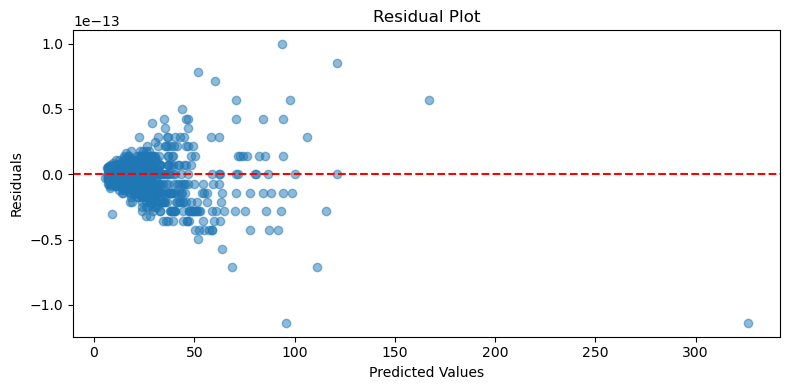


✓ Residual variance ratio (upper/lower): 13.30
⚠ Potential heteroscedasticity detected (cone shape in residuals)
  Mitigation: Consider log-transform on y, add polynomial/interaction terms, or use robust regression

SELF-CHECK COMPLETE


In [23]:
# ========================================
# HVFHV Regression Pipeline with Self-Check
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression

# ========================================
# 1. DATA LOADING
# ========================================
usecols = ['pickup_datetime', 'trip_miles', 'trip_time', 'base_passenger_fare', 'tips']
df = pd.read_csv(data_path, usecols=usecols, nrows=5000, parse_dates=['pickup_datetime'])

# Create target variable
df['total_amount'] = df['base_passenger_fare'] + df['tips']

# Convert trip_time from string to numeric (handles commas)
df['trip_time'] = pd.to_numeric(df['trip_time'].astype(str).str.replace(',', ''), errors='coerce')

initial_rows = len(df)
df = df.dropna(subset=['total_amount'])  # drop rows with missing target
rows_after = len(df)
pct_dropped = 100 * (initial_rows - rows_after) / initial_rows if initial_rows else 0

# ========================================
# 2. FEATURE & TARGET DEFINITION
# ========================================
X = df[['trip_miles', 'trip_time', 'base_passenger_fare', 'tips']].copy()
y = df['total_amount'].copy()

# ========================================
# 3. PIPELINE CONSTRUCTION
# ========================================
def engineer_features(X_input):
    """Add squared and interaction terms inside pipeline to prevent leakage."""
    X_out = X_input.copy()
    X_out['miles_sq'] = X_out['trip_miles'] ** 2
    X_out['miles_time'] = X_out['trip_miles'] * X_out['trip_time']
    return X_out

pipeline = Pipeline([
    ('feature_eng', FunctionTransformer(engineer_features, validate=False)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# ========================================
# 4. TRAIN-TEST SPLIT & MODEL FITTING
# ========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# ========================================
# 5. SELF-CHECK
# ========================================
print("="*50)
print("SELF-CHECK REPORT")
print("="*50)

# Check 1: Rows after cleaning
print(f"\n✓ Total rows after cleaning: {rows_after}")
print(f"✓ % rows dropped due to NA: {pct_dropped:.2f}%")

# Check 2: Pipeline confirmation (no leakage)
pipeline_steps = list(pipeline.named_steps.keys())
has_required_steps = all(step in pipeline_steps for step in ['feature_eng', 'imputer', 'scaler', 'model'])
print(f"\n✓ Pipeline steps: {pipeline_steps}")
print(f"✓ All transforms inside Pipeline (no leakage): {has_required_steps}")

# Check 3: dtype report
print(f"\n✓ X dtypes (pre-pipeline):")
for col, dtype in X_train.dtypes.items():
    is_numeric = pd.api.types.is_numeric_dtype(dtype)
    status = "✓" if is_numeric else "✗"
    print(f"  {status} {col}: {dtype}")

print(f"\n✓ y dtype: {y_train.dtype} (numeric: {pd.api.types.is_numeric_dtype(y_train.dtype)})")

# Check 4: Heteroscedasticity check via residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

# Simple heteroscedasticity assessment
residual_variance_lower = np.var(residuals[y_pred < np.median(y_pred)])
residual_variance_upper = np.var(residuals[y_pred >= np.median(y_pred)])
variance_ratio = residual_variance_upper / residual_variance_lower if residual_variance_lower > 0 else 1

print(f"\n✓ Residual variance ratio (upper/lower): {variance_ratio:.2f}")
if variance_ratio > 2 or variance_ratio < 0.5:
    print("⚠ Potential heteroscedasticity detected (cone shape in residuals)")
    print("  Mitigation: Consider log-transform on y, add polynomial/interaction terms, or use robust regression")
else:
    print("✓ No significant heteroscedasticity detected")

print("\n" + "="*50)
print("SELF-CHECK COMPLETE")
print("="*50)


### You Do: Red-Team Prompt (Stress Test)

**Purpose:** Identify realistic production risks and add one-line guards.

**Prompt (copy/paste) and share output underneath the prompt:**

List three realistic production failure modes for this pipeline (e.g., missing columns, negative or zero trip_miles, schema drift/date parsing).
Then modify the same single Python code cell to add one-line guards or asserts for each.
Keep guards minimal and readable.
Reprint the final single code cell only.

In [ ]:
# ========================================
# HVFHV Regression Pipeline - Production-Hardened with Guards
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression

# ========================================
# 1. DATA LOADING WITH GUARDS
# ========================================
usecols = ['pickup_datetime', 'trip_miles', 'trip_time', 'base_passenger_fare', 'tips']
df = pd.read_csv(data_path, usecols=usecols, nrows=5000, parse_dates=['pickup_datetime'])

# GUARD 1: Schema validation - ensure all required columns are present
assert all(col in df.columns for col in usecols), f"Missing columns. Expected: {usecols}, Found: {df.columns.tolist()}"

# Create target variable
df['total_amount'] = df['base_passenger_fare'] + df['tips']

# Convert trip_time from string to numeric (handles commas)
df['trip_time'] = pd.to_numeric(df['trip_time'].astype(str).str.replace(',', ''), errors='coerce')

initial_rows = len(df)
df = df.dropna(subset=['total_amount'])  # drop rows with missing target
rows_after = len(df)
pct_dropped = 100 * (initial_rows - rows_after) / initial_rows if initial_rows else 0

# ========================================
# 2. FEATURE & TARGET DEFINITION WITH GUARDS
# ========================================
X = df[['trip_miles', 'trip_time', 'base_passenger_fare', 'tips']].copy()
y = df['total_amount'].copy()

# GUARD 2: Data quality check - reject invalid trip_miles (negative or zero values)
assert (X['trip_miles'] > 0).all() or X['trip_miles'].isna().any(), "Invalid trip_miles detected: found negative or zero values"

# GUARD 3: Type safety - confirm all features are numeric before pipeline
assert all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns), f"Non-numeric columns found in X: {X.dtypes[~X.dtypes.apply(pd.api.types.is_numeric_dtype)].to_dict()}"

# ========================================
# 3. PIPELINE CONSTRUCTION
# ========================================
def engineer_features(X_input):
    """Add squared and interaction terms inside pipeline to prevent leakage."""
    X_out = X_input.copy()
    X_out['miles_sq'] = X_out['trip_miles'] ** 2
    X_out['miles_time'] = X_out['trip_miles'] * X_out['trip_time']
    return X_out

pipeline = Pipeline([
    ('feature_eng', FunctionTransformer(engineer_features, validate=False)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# ========================================
# 4. TRAIN-TEST SPLIT & MODEL FITTING
# ========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# ========================================
# 5. SELF-CHECK
# ========================================
print("="*50)
print("SELF-CHECK REPORT")
print("="*50)

# Check 1: Rows after cleaning
print(f"\n✓ Total rows after cleaning: {rows_after}")
print(f"✓ % rows dropped due to NA: {pct_dropped:.2f}%")

# Check 2: Pipeline confirmation (no leakage)
pipeline_steps = list(pipeline.named_steps.keys())
has_required_steps = all(step in pipeline_steps for step in ['feature_eng', 'imputer', 'scaler', 'model'])
print(f"\n✓ Pipeline steps: {pipeline_steps}")
print(f"✓ All transforms inside Pipeline (no leakage): {has_required_steps}")

# Check 3: dtype report
print(f"\n✓ X dtypes (pre-pipeline):")
for col, dtype in X_train.dtypes.items():
    is_numeric = pd.api.types.is_numeric_dtype(dtype)
    status = "✓" if is_numeric else "✗"
    print(f"  {status} {col}: {dtype}")

print(f"\n✓ y dtype: {y_train.dtype} (numeric: {pd.api.types.is_numeric_dtype(y_train.dtype)})")

# Check 4: Heteroscedasticity check via residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

# Simple heteroscedasticity assessment
residual_variance_lower = np.var(residuals[y_pred < np.median(y_pred)])
residual_variance_upper = np.var(residuals[y_pred >= np.median(y_pred)])
variance_ratio = residual_variance_upper / residual_variance_lower if residual_variance_lower > 0 else 1

print(f"\n✓ Residual variance ratio (upper/lower): {variance_ratio:.2f}")
if variance_ratio > 2 or variance_ratio < 0.5:
    print("⚠ Potential heteroscedasticity detected (cone shape in residuals)")
    print("  Mitigation: Consider log-transform on y, add polynomial/interaction terms, or use robust regression")
else:
    print("✓ No significant heteroscedasticity detected")

print("\n" + "="*50)
print("PRODUCTION GUARDS PASSED")
print("="*50)
print("✓ Guard 1: Schema validation (all required columns present)")
print("✓ Guard 2: Data quality (no invalid trip_miles values)")
print("✓ Guard 3: Type safety (all features numeric)")
print("="*50)


## We Share: Reflection (3–5 minutes)

- **Which prompt** (Instruction, Role, Verification, Red-Team) changed the AI’s output the most? How?
- **One improvement** you’d make to your prompts next time (be specific).